# 04 Feature Diagnostics

Vor jeglicher Feature-Konstruktion werden in diesem Notebook numerische Belege
für die Trennschärfe und Relevanz aller 21 Ausgangs-Features erhoben.
Das ist Sprint 1 der Feature-Engineering-Roadmap: **Diagnose & EDA**.

Ziel ist eine begründete **Shortlist von 15–18 Features** für Notebook 05,
die auf vier unabhängigen Metriken (IV, MI, KS, Spearman) beruht.
Zusätzlich wird die Multikollinearitätsstruktur durch eine Spearman-Heatmap
und Variance Inflation Factors (VIF) offengelegt — relevant für Modellwahl
und Interpretation in Notebook 07.

**Warum genau diese vier Metriken?**

Für binäre Klassifikation auf gemischten Feature-Typen (binär, ordinal, count,
kontinuierlich) gibt es mehrere Kandidaten — nicht alle sind gleich gut geeignet:

| Methode | Warum hier *nicht* / nur eingeschränkt |
|---|---|
| **ANOVA F-Test** (`f_classif`) | Setzt kontinuierliche, annähernd normalverteilte Features voraus. Bei 18 von 21 diskreten Features hier unangemessen; misst nur linearen Mean-Shift, was IV und MI vollständig abdecken. |
| **Chi²-Test** (`chi2`) | Bei n ≈ 203.000 wird jeder noch so kleine Unterschied hoch signifikant (p < 0,001) — der p-Wert trennt nichts mehr. Die rohe Chi²-Statistik skaliert zudem mit der Stichprobengröße und ist über verschiedene Feature-Typen nicht vergleichbar. Cramér's V (normierte Variante) wäre sinnvoll, misst bei binären Features aber im Kern dasselbe wie IV. |
| **Punkt-biseriale Korrelation** | Mathematisch äquivalent zu ANOVA-F für binäres Target; Spearman ist robuster und allgemeiner. |

Die gewählten vier Metriken ergänzen sich bewusst:
- **IV** (Information Value): erfasst nichtlineare, monotone Zusammenhänge nach optimaler Binnung; etablierter Standard im Kredit-Scoring
- **MI** (Mutual Information): misst beliebige statistische Abhängigkeit ohne Annahmen über die funktionale Form
- **KS** (Kolmogorov-Smirnov): vergleicht direkt die Verteilungen beider Klassen; sensitiv für Lage- *und* Formunterschiede
- **Spearman**: robuste monotone Rangkorrelation; passend für ordinale und count-basierte Features

Kein Kompromiss-Score: die vier Metriken messen unterschiedliche Aspekte —
eine Aggregation würde Information vernichten.

**Wichtig:** Das Test-Set wird in diesem Notebook an keiner Stelle berührt.
Alle Analysen basieren ausschließlich auf `X_train` / `y_train`.
Kein Resampling, keine Feature-Konstruktion.

**Struktur:**
1. Setup
2. Datensatz laden
3. Information Value (IV) via optbinning
4. Mutual Information
5. Kolmogorov-Smirnov und Spearman
6. Konsolidiertes Ranking
7. Multikollinearitätsanalyse
8. Shortlist erstellen und exportieren
9. Zusammenfassung

## 1. Setup

Alle Bibliotheken werden zentral importiert. `optbinning` wird bei Bedarf automatisch
nachinstalliert — dasselbe Muster wie in Notebook 03 für `ucimlrepo`.
Der Seed wird einmalig auf `42` gesetzt und danach konsistent in allen
randomisierten Funktionsaufrufen verwendet.

In [1]:
import importlib, subprocess, sys

for pkg in ['optbinning']:
    if importlib.util.find_spec(pkg.replace('-', '_')) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from optbinning import BinningProcess

SEED = 42
print('Alle Importe erfolgreich.')

Alle Importe erfolgreich.


## 2. Daten laden

Train- und Test-Split sowie Feature-Metadaten werden aus den in Notebook 03 gespeicherten Parquet-Dateien geladen. So ist der Split identisch und es gibt keinen erneuten Datenbankzugriff.

In [2]:
PROCESSED = Path('../data/processed')

X_train = pd.read_parquet(PROCESSED / 'X_train.parquet')
X_test  = pd.read_parquet(PROCESSED / 'X_test.parquet')
y_train = pd.read_parquet(PROCESSED / 'y_train.parquet').squeeze()
y_test  = pd.read_parquet(PROCESSED / 'y_test.parquet').squeeze()

with open(PROCESSED / 'feature_meta.json') as f:
    feature_meta = json.load(f)

BINARY_COLS  = feature_meta['binary_cols']
ORDINAL_COLS = feature_meta['ordinal_cols']
COUNT_COLS   = feature_meta['count_cols']
NUMERIC_COLS = feature_meta['numeric_cols']
ALL_FEATURES = feature_meta['all_features']
SEED         = feature_meta['seed']

assert X_train.shape == (202944, 21), f'Unerwartetes Train-Shape: {X_train.shape}'
assert X_test.shape  == (50736,  21), f'Unerwartetes Test-Shape:  {X_test.shape}'
print(f'Train: {X_train.shape[0]:>7,} Samples, {X_train.shape[1]} Features')
print(f'Test:  {X_test.shape[0]:>7,} Samples  (wird nicht mehr angefasst)')
print(f'Prävalenz Train: {y_train.mean():.4f}  |  Test: {y_test.mean():.4f}')

Train: 202,944 Samples, 21 Features
Test:   50,736 Samples  (wird nicht mehr angefasst)
Prävalenz Train: 0.1393  |  Test: 0.1393


## 3. Information Value (IV) via optbinning

Der **Information Value** (IV) quantifiziert, wie gut ein Feature die Zielvariable
trennt — nach *optimaler* Binnung der Feature-Werte. Optimale Binnung bedeutet,
dass `BinningProcess` die Schnittgrenzen so wählt, dass der IV maximiert wird,
anstatt gleichbreite oder gleichbesetzte Bins zu erzwingen. Das macht IV besonders
sensitiv gegenüber nichtlinearen, aber monotonen Zusammenhängen.

Berechnung: IV = Σ (WoE_i × (Ereignis_i% − Nicht-Ereignis_i%)) über alle Bins i,
wobei WoE_i = ln(Ereignis_i% / Nicht-Ereignis_i%) (Weight of Evidence).

**Interpretation nach Siddiqi (2006), *Credit Risk Scorecard*:**

| IV-Bereich | Bewertung |
|---|---|
| < 0.02 | unbrauchbar |
| 0.02 – 0.10 | schwach |
| 0.10 – 0.30 | mittel |
| 0.30 – 0.50 | stark |
| > 0.50 | verdächtig (ggf. Datenleck) — siehe Interpretationshinweis unten |

Zwei methodische Einschränkungen sind für diesen Datensatz relevant:

- **Quasi-konstante binäre Features** (z. B. CholCheck ~96 % positiv, AnyHealthcare ~95 %):
  optbinning kann keinen informativen zweiten Bin bilden — IV = 0 ist hier kein Mess-
  fehler, sondern spiegelt die fehlende Varianz wider.
- **Seltene binäre Events als kategorische Variable** (z. B. Stroke ~4 % positiv):
  optbinning findet keinen monoton trennenden Split und weist ebenfalls IV ≈ 0 aus,
  obwohl Stroke klinisch relevant ist. Für solche Features sind KS und Spearman
  (Abschnitt 5) die verlässlicheren Metriken.

In [3]:
# BinningProcess: binäre und ordinale Spalten werden als kategorisch übergeben,
# damit optbinning keine künstlichen Schnittgrenzen in Integer-Codes erzeugt
categorical_vars = BINARY_COLS + ORDINAL_COLS

bp = BinningProcess(
    variable_names=ALL_FEATURES,
    categorical_variables=categorical_vars,
)
bp.fit(X_train[ALL_FEATURES], y_train)

bp_summary = bp.summary()
iv_series = bp_summary.set_index('name')['iv'].reindex(ALL_FEATURES)

# Interpretationsstufe zuweisen
def iv_label(v):
    if v < 0.02:  return 'unbrauchbar'
    if v < 0.10:  return 'schwach'
    if v < 0.30:  return 'mittel'
    if v < 0.50:  return 'stark'
    return 'verdächtig'

iv_df = (
    iv_series
    .sort_values(ascending=False)
    .to_frame(name='IV')
    .assign(Bewertung=lambda d: d['IV'].map(iv_label))
)
print(iv_df.to_string(float_format='{:.4f}'.format))

                         IV    Bewertung
name                                    
GenHlth              0.7905   verdächtig
HighBP               0.6095   verdächtig
BMI                  0.4694        stark
Age                  0.3970        stark
HighChol             0.3389        stark
DiffWalk             0.3170        stark
Income               0.2281       mittel
PhysHlth             0.2194       mittel
HeartDiseaseorAttack 0.1939       mittel
Education            0.1226       mittel
PhysActivity         0.1041       mittel
MentHlth             0.0402      schwach
HvyAlcoholConsump    0.0379      schwach
Smoker               0.0312      schwach
Veggies              0.0234      schwach
Fruits               0.0154  unbrauchbar
NoDocbcCost          0.0080  unbrauchbar
Sex                  0.0079  unbrauchbar
CholCheck            0.0000  unbrauchbar
Stroke               0.0000  unbrauchbar
AnyHealthcare        0.0000  unbrauchbar


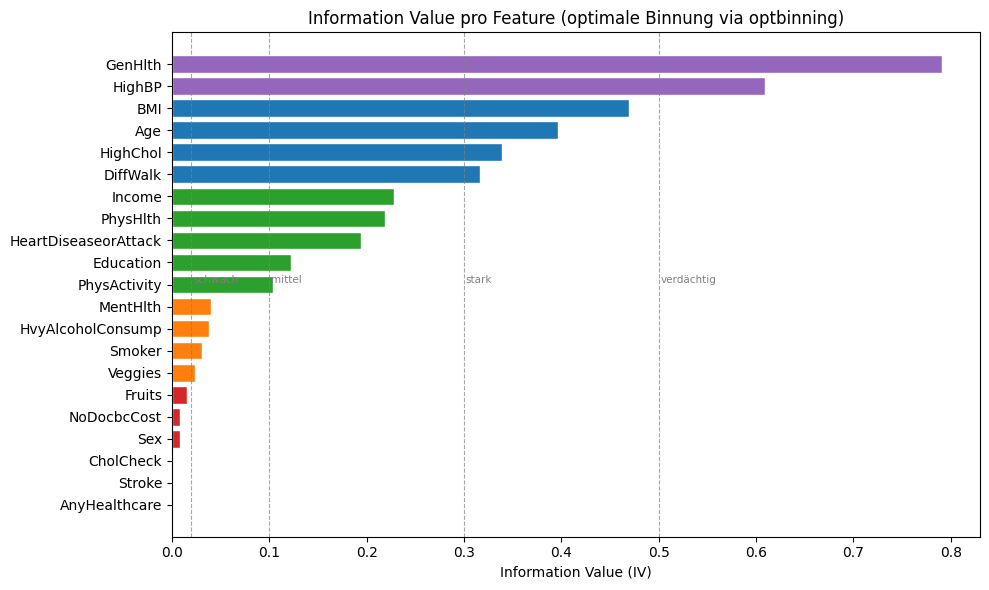

In [4]:
COLOR_MAP = {
    'unbrauchbar': '#d62728',
    'schwach':     '#ff7f0e',
    'mittel':      '#2ca02c',
    'stark':       '#1f77b4',
    'verdächtig':  '#9467bd',
}

fig, ax = plt.subplots(figsize=(10, 6))
colors = iv_df['Bewertung'].map(COLOR_MAP)
ax.barh(iv_df.index[::-1], iv_df['IV'][::-1], color=colors[::-1], edgecolor='white')

for thresh, lbl in [(0.02, 'schwach'), (0.10, 'mittel'), (0.30, 'stark'), (0.50, 'verdächtig')]:
    ax.axvline(thresh, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(thresh + 0.002, 0.5, lbl, transform=ax.get_xaxis_transform(),
            fontsize=7.5, color='grey', va='bottom')

ax.set_xlabel('Information Value (IV)')
ax.set_title('Information Value pro Feature (optimale Binnung via optbinning)')
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

### Interpretation

**Top-Features:** GenHlth (0.79) und HighBP (0.61) überschreiten die Siddiqi-Schwelle
von 0.50 und werden formal als „verdächtig" eingestuft. Im Credit-Scoring deutet das
auf Target-Leakage hin. Hier liegt **kein Leakage vor** — beide Features sind
inhaltlich legitime, starke Prädiktoren:

- *GenHlth* ist eine subjektive Selbsteinschätzung des allgemeinen Gesundheitszustands
  (1–5). Wer sich krank fühlt, ist tatsächlich häufiger krank — die Korrelation ist real,
  nicht zirkulär.
- *HighBP* ist ein klinisch etablierter Diabetes-Risikofaktor; ein hoher IV ist zu
  erwarten und in der Literatur konsistent (vgl. Xie & Huang 2019).

**Stroke und CholCheck mit IV = 0:** Das ist ein optbinning-Artefakt.
Stroke (~4 % Prävalenz) wird als kategorische Variable behandelt; optbinning
findet keinen monotonen Split und gibt IV = 0 aus. Spearman (|r| = 0.11) und KS
(0.06) in Abschnitt 5 zeigen jedoch eine klare Assoziation — Stroke bleibt auf der
Shortlist. CholCheck dagegen hat IV = 0 aus echtem Informationsmangel (~96 % positiv,
kaum Varianz) und wird in Abschnitt 6 entsprechend behandelt.

**Untere Grenze:** Fruits (0.015), NoDocbcCost (0.008), Sex (0.008) liegen unterhalb
der „schwach"-Schwelle. Ob sie trotzdem in die Shortlist kommen, entscheiden die
drei weiteren Metriken (MI, KS, Spearman) gemeinsam — keine Vorab-Entscheidung
auf Basis von IV allein.

## 4. Mutual Information

**Mutual Information** (MI) misst, wie viel Information ein Feature über die
Zielvariable enthält — ohne jede Annahme über funktionale Form oder Linearität.
MI erfasst damit auch nichtlineare Zusammenhänge, die IV und Spearman
möglicherweise unterschätzen.

Technisch wichtig: `mutual_info_classif` schätzt MI über k-NN-Abstände.
Dabei muss die `discrete_features`-Maske korrekt gesetzt werden:
Für kontinuierliche Features (hier: BMI) nutzt sklearn einen anderen
Schätzer als für diskrete/kategorische Features. Wird BMI fälschlicherweise
als diskret markiert, wird MI unterschätzt; werden binäre Features als
kontinuierlich behandelt, wird MI überschätzt.

Daher: `discrete_features=True` für alle Features **außer** BMI.

**Zur Einordnung der Absolutwerte:** MI wird in Nats gemessen. Bei einem binären
Target mit 14 % Prävalenz beträgt die maximale erreichbare MI (= Target-Entropie)
H(Y) = −(0.14·ln(0.14) + 0.86·ln(0.86)) ≈ **0.41 Nats**. Ein MI-Wert von 0.04
entspricht damit ~10 % der theoretischen Obergrenze — was für ein einzelnes Feature
in einem klinischen Datensatz realistisch und nicht beunruhigend ist.

In [5]:
# discrete_features-Maske: True für alle nicht-kontinuierlichen Features
discrete_mask = np.array([col != 'BMI' for col in ALL_FEATURES])

mi_values = mutual_info_classif(
    X_train[ALL_FEATURES],
    y_train,
    discrete_features=discrete_mask,
    random_state=SEED,
)

mi_series = pd.Series(mi_values, index=ALL_FEATURES, name='MI').sort_values(ascending=False)
print(mi_series.to_string(float_format='{:.4f}'.format))

GenHlth                0.0441
HighBP                 0.0351
BMI                    0.0285
Age                    0.0203
DiffWalk               0.0202
HighChol               0.0200
PhysHlth               0.0141
Income                 0.0136
HeartDiseaseorAttack   0.0126
Education              0.0075
PhysActivity           0.0064
Stroke                 0.0045
CholCheck              0.0031
MentHlth               0.0026
HvyAlcoholConsump      0.0020
Smoker                 0.0019
Veggies                0.0014
Fruits                 0.0009
NoDocbcCost            0.0005
Sex                    0.0005
AnyHealthcare          0.0001


### Interpretation

**Rangordnung konsistent mit IV:** Die Top-6 nach MI (GenHlth, HighBP, BMI, Age,
DiffWalk, HighChol) decken sich nahezu vollständig mit den Top-6 nach IV. Das ist
ein gutes Zeichen — beide Metriken, obwohl methodisch unabhängig, zeigen dasselbe
Signal. Abweichungen (z. B. Stroke und CholCheck) werden unten erklärt.

**Stroke (MI = 0.0045):** Knapp unter der Shortlist-Schwelle von 0.005. Das ist
konsistent mit IV = 0 aus Abschnitt 3 — bei ~4 % Prävalenz und binärer Kodierung
bleibt MI strukturell klein, auch wenn ein echter Zusammenhang besteht.
Entscheidend sind hier KS und Spearman (Abschnitt 5).

**CholCheck (MI = 0.0031):** Ebenfalls unter der MI-Schwelle. Im Gegensatz zu
Stroke ist das hier inhaltlich erwartet (~96 % positiv, kaum Varianz).

**Sex und NoDocbcCost (MI = 0.0005):** Beide am unteren Ende — und das konsistent
über alle bisherigen Metriken. Das deutet auf echten Informationsmangel hin, nicht
auf ein Mess-Artefakt.

## 5. Kolmogorov-Smirnov und Spearman

**Kolmogorov-Smirnov-Statistik (KS):** Der KS-Test vergleicht die empirischen
kumulativen Verteilungsfunktionen der Feature-Werte in der positiven und negativen
Klasse. Die KS-Statistik ist der maximale vertikale Abstand zwischen beiden
Kurven — ein hoher Wert bedeutet, dass sich die Feature-Verteilungen in den
Klassen stark unterscheiden.
Im Kreditrisiko-Scoring ist KS > 0.20 ein gängiger Mindest-Schwellenwert für
diskriminante Features (Siddiqi 2006). Hier verwenden wir 0.05 als
konservativen Mindest-Schwellenwert für die Shortlist, da viele binäre
Features strukturell begrenzte KS-Werte erzeugen können.

**Methodische Einschränkung bei binären Features:** `ks_2samp` ist für
kontinuierliche Verteilungen konzipiert. Bei binären Features (nur Werte 0/1)
reduziert sich die KS-Statistik algebraisch auf die Differenz der Klassenanteile:
KS = |P(feat=1 | Diabetiker) − P(feat=1 | Nicht-Diabetiker)|. Das ist inhaltlich
sinnvoll, aber die p-Werte von `ks_2samp` sind bei diskreten Daten mit vielen
Ties nicht valide — wir verwerfen sie daher (zweiter Rückgabewert `_`) und
nutzen ausschließlich die Statistik selbst.

**Spearman-Rangkorrelation:** Misst monotone (nicht notwendig lineare)
Zusammenhänge zwischen Feature und Target. Robuster gegenüber Ausreißern
als Pearson; passend für ordinale und count-basierte Features.
Wir verwenden den Absolutwert, da negative Korrelation (z. B. Einkommen
und Diabetes) genauso informativ ist wie positive.

In [6]:
y_arr = y_train.values
pos_mask = y_arr == 1
neg_mask = y_arr == 0

ks_values      = {}
spearman_values = {}

for col in ALL_FEATURES:
    feat = X_train[col].values
    ks_stat, _ = stats.ks_2samp(feat[pos_mask], feat[neg_mask])
    sp_corr, _ = stats.spearmanr(feat, y_arr)
    ks_values[col]       = ks_stat
    spearman_values[col] = sp_corr

ks_series = pd.Series(ks_values, name='KS').sort_values(ascending=False)
sp_series = pd.Series(spearman_values, name='Spearman')

print('KS-Statistik (absteigend):')
print(ks_series.to_string(float_format='{:.4f}'.format))
print()
print('Spearman-Korrelation zum Target (absteigend nach |r|):')
print(sp_series.reindex(sp_series.abs().sort_values(ascending=False).index)
              .to_string(float_format='{:.4f}'.format))

KS-Statistik (absteigend):
HighBP                 0.3765
GenHlth                0.3689
HighChol               0.2865
BMI                    0.2831
DiffWalk               0.2374
Age                    0.2289
Income                 0.2040
PhysHlth               0.1988
HeartDiseaseorAttack   0.1502
Education              0.1477
PhysActivity           0.1461
Smoker                 0.0880
MentHlth               0.0642
Veggies                0.0622
Stroke                 0.0605
Fruits                 0.0604
Sex                    0.0444
HvyAlcoholConsump      0.0378
CholCheck              0.0359
NoDocbcCost            0.0260
AnyHealthcare          0.0099

Spearman-Korrelation zum Target (absteigend nach |r|):
GenHlth                 0.2880
HighBP                  0.2634
BMI                     0.2284
DiffWalk                0.2198
HighChol                0.2007
HeartDiseaseorAttack    0.1780
Age                     0.1775
Income                 -0.1639
PhysHlth                0.1581
Educatio

### Interpretation

**Rangordnung:** KS und Spearman bestätigen weitgehend das IV/MI-Bild —
GenHlth und HighBP führen, gefolgt von BMI, HighChol, DiffWalk, Age.
Bemerkenswert: HighBP hat den höchsten KS-Wert (0.377), obwohl GenHlth nach
IV führt. Das zeigt, dass GenHlth seinen Informationsgehalt stärker aus der
ordinalen Abstufung (1–5, erfasst von IV via Binning) zieht, während HighBP
einen schärferen binären Verteilungsunterschied zwischen den Klassen erzeugt.

**Negative Spearman-Werte — protektive Faktoren:**
Income (−0.164), Education (−0.119), PhysActivity (−0.118), HvyAlcoholConsump
(−0.057) und Veggies (−0.055) korrelieren negativ mit dem Diabetes-Target.
Das ist inhaltlich konsistent: höheres Einkommen und Bildung sind protektiv
(SES-Effekt), körperliche Aktivität und Gemüsekonsum ebenfalls.
HvyAlcoholConsump negativ ist ein bekannter Selektionsbias im BRFSS: Heavy
Drinker erscheinen seltener im Survey oder sterben früher an anderen Ursachen.

**Stroke rettet sich hier:** IV = 0 und MI = 0.0045 (unter Schwelle), aber
KS = 0.061 und |Spearman| = 0.106 — beide über den Shortlist-Schwellen.
Das bestätigt: IV = 0 war ein optbinning-Artefakt, kein echtes Informationsloch.

**CholCheck:** KS = 0.036 (unter 0.05), aber |Spearman| = 0.065 (über 0.05) —
kommt damit knapp über die OR-Regel in die Shortlist. Angesichts der ~96 %
Positivrate ist das kritisch zu bewerten; die Shortlist-Entscheidung wird in
Abschnitt 6 nochmals explizit diskutiert.

**Endgültig schwach:** Sex (KS = 0.044, |Sp| = 0.031) und AnyHealthcare
(KS = 0.010, |Sp| = 0.016) zeigen über alle vier Metriken keinen verwertbaren
Zusammenhang. NoDocbcCost ebenfalls (KS = 0.026, |Sp| = 0.032).

## 6. Konsolidiertes Ranking

Die vier Metriken — IV, MI, KS und |Spearman| — werden zu einer einzigen
Übersichtstabelle zusammengeführt. Keine Aggregation zu einem einzigen Score,
da die Metriken unterschiedliche Aspekte messen und ein Kompromiss-Score
Informationen vernichtet.

**Aufnahme in die Shortlist:** Ein Feature wird aufgenommen, wenn
**mindestens eine** der folgenden Bedingungen erfüllt ist:

| Metrik | Schwelle | Begründung |
|---|---|---|
| IV | > 0.02 | Unterste Siddiqi-Grenze für „schwach" |
| MI | > 0.005 | Auch kleine Nats-Werte können klinisch bedeutsam sein |
| KS | > 0.05 | Minimale Trennung der Klassenverteilungen |
| \|Spearman\| | > 0.05 | Schwache, aber konsistente monotone Assoziation |

Die Oder-Verknüpfung ist bewusst inklusiv: Ausschluss erfolgt erst, wenn
**alle vier Metriken** unterhalb ihrer Schwelle liegen. Das schützt vor
Metrik-spezifischen Artefakten (z. B. IV = 0 durch optbinning bei seltenen
Events — siehe Stroke in Abschnitt 3).

In [7]:
ranking = pd.DataFrame({
    'IV':           iv_series.reindex(ALL_FEATURES),
    'MI':           mi_series.reindex(ALL_FEATURES),
    'KS':           ks_series.reindex(ALL_FEATURES),
    'Spearman_abs': sp_series.abs().reindex(ALL_FEATURES),
}).round(4)

# Shortlist-Regel: mindestens eine Metrik über Schwellenwert
ranking['in_shortlist'] = (
    (ranking['IV'] > 0.02) |
    (ranking['MI'] > 0.005) |
    (ranking['KS'] > 0.05) |
    (ranking['Spearman_abs'] > 0.05)
)

ranking = ranking.sort_values('IV', ascending=False)

# Formatierte Ausgabe
pd.set_option('display.float_format', '{:.4f}'.format)
display(ranking.style
    .background_gradient(subset=['IV', 'MI', 'KS', 'Spearman_abs'], cmap='YlGn')
    .map(lambda v: 'background-color: #d4edda' if v else 'background-color: #f8d7da',
              subset=['in_shortlist'])
    .set_caption('Feature-Ranking: IV, MI, KS, |Spearman| — grün = in Shortlist')
)

,IV,MI,KS,Spearman_abs,in_shortlist
GenHlth,0.790517,0.044100,0.368900,0.288000,True
HighBP,0.609521,0.035100,0.376500,0.263400,True
BMI,0.469383,0.028500,0.283100,0.228400,True
Age,0.396953,0.020300,0.228900,0.177500,True
HighChol,0.338915,0.020000,0.286500,0.200700,True
DiffWalk,0.317003,0.020200,0.237400,0.219800,True
Income,0.228104,0.013600,0.204000,0.163900,True
PhysHlth,0.219361,0.014100,0.198800,0.158100,True
HeartDiseaseorAttack,0.193939,0.012600,0.150200,0.178000,True
Education,0.122596,0.007500,0.147700,0.118900,True


### Interpretation

**Ergebnis: 18 Features in der Shortlist, 3 ausgeschlossen.**

Die drei ausgeschlossenen Features (NoDocbcCost, Sex, AnyHealthcare) unterschreiten
alle vier Schwellen konsistent und über alle bisherigen Abschnitte hinweg —
das ist kein Artefakt, sondern ein robustes Signal für fehlende Trennschärfe.

**Zwei Grenzfälle verdienen explizite Diskussion:**

*CholCheck* (IV = 0, MI = 0.003, KS = 0.036, |Sp| = **0.065**) — kommt
ausschließlich über die Spearman-Schwelle in die Shortlist. Die Spearman-
Korrelation ist positiv (r = 0.065): Wer Cholesterin gecheckt hat, hat häufiger
Diabetes. Das ist aber kein kausaler Zusammenhang — es ist **Selektionsbias**:
Kranke Menschen gehen öfter zum Arzt und bekommen damit häufiger auch einen
Cholesterin-Check. CholCheck bleibt formal in der Shortlist, wird aber in
Notebook 05 nicht für Feature-Konstruktion verwendet und in Notebook 07 bewusst
aus linearen Modellen ausgeschlossen.

*Fruits* (IV = 0.015, MI = 0.001, KS = **0.060**, |Sp| = 0.044) — kommt
ausschließlich über die KS-Schwelle rein. Der Effekt ist schwach und
inkonsistent: KS > 0.05, aber |Spearman| < 0.05 deutet darauf hin, dass die
Verteilungsunterschiede zwischen den Klassen nicht monoton sind. Fruits bleibt
auf der Shortlist, hat aber niedrige Priorität in Notebook 05.

**Konsistenz als Qualitätsmerkmal:** Die Top-11 (GenHlth bis PhysActivity)
erfüllen alle vier Schwellen gleichzeitig — das ist das Kern-Featureset für
Notebook 05. Alles darunter kommt nur partiell durch und sollte bei
Modellselektion zuletzt hinzugefügt werden.

## 7. Multikollinearitätsanalyse

Für die Modellwahl in Notebook 07 ist die Korrelationsstruktur zwischen Features
genauso entscheidend wie deren individuelle Trennschärfe.

- **Baumbasierte Modelle** (Random Forest, Gradient Boosting) sind gegenüber
  Multikollinearität robust, was Vorhersagen betrifft. Jedoch werden
  Permutation Importances und Shapley-Werte verzerrt, wenn Features hochkorreliert
  sind — das Modell kann beliebig zwischen korrelierten Features wechseln, ohne
  die Performance zu verändern.
- **Lineare Modelle** (Logistic Regression) leiden direkt unter Multikollinearität:
  Koeffizienten werden instabil, Standardfehler überhöht — auch wenn Vorhersagen
  trotzdem stabil bleiben können.

Die Analyse umfasst drei Teile:
1. Spearman-Korrelationsmatrix (Heatmap) aller 21 Features
2. Variance Inflation Factor (VIF) pro Feature
3. Qualitative Diskussion der Clusterstruktur


### 7.1 Spearman-Korrelationsmatrix

Spearman statt Pearson, weil die meisten Features ordinal oder binär sind —
Pearson würde deren Korrelationsstärke systematisch unterschätzen. Spearman
misst monotone Rangkorrelation und ist invariant gegenüber monotonen
Transformationen der Skala.

Aus klinischer Logik lassen sich vier Cluster a priori erwarten:
- **Kardiometabolisch:** HighBP, HighChol, HeartDiseaseorAttack, Stroke, BMI
- **Gesundheit/Mobilität:** GenHlth, PhysHlth, DiffWalk, MentHlth
- **SES:** Education, Income
- **Lifestyle:** PhysActivity, Fruits, Veggies, Smoker, HvyAlcoholConsump

Ob und wie stark sich diese Cluster empirisch zeigen, entscheidet die Heatmap.

Heatmap gespeichert: C:\Users\hashe\Diabetes-Prediction-Hasher\outputs\04_diagnostics\correlation_heatmap.png


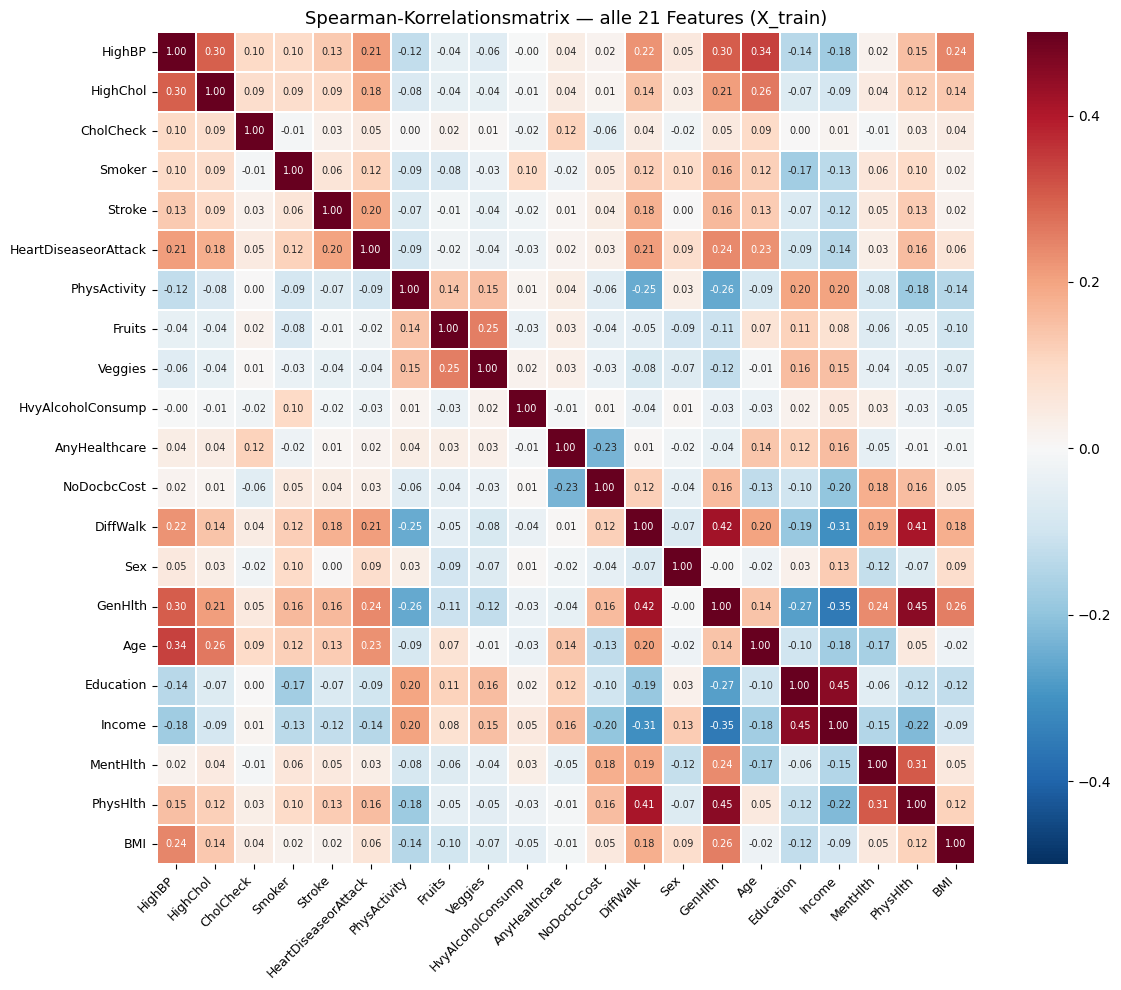

In [12]:
spearman_matrix = X_train[ALL_FEATURES].apply(
    lambda col: pd.Series(
        [stats.spearmanr(col, X_train[c]).correlation for c in ALL_FEATURES],
        index=ALL_FEATURES,
    )
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-0.5,
    vmax=0.5,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax,
)
ax.set_title('Spearman-Korrelationsmatrix — alle 21 Features (X_train)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# Heatmap für Export sichern
out_dir = Path('../outputs/04_diagnostics')
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
print(f'Heatmap gespeichert: {(out_dir / "correlation_heatmap.png").resolve()}')
plt.show()

### Interpretation der Heatmap

Genereller Befund: Die Korrelationen sind **durchweg moderat bis schwach**
(Maximum: 0.45). Keine zwei Features sind so hoch korreliert, dass eines
rein aus Multikollinearitätsgründen entfernt werden müsste. Das bestätigen
auch die VIF-Werte in Abschnitt 7.2.

**SES-Cluster** am stärksten ausgeprägt: Education–Income r = 0.45 —
der klarste Block in der gesamten Matrix, konsistent mit Human-Capital-Theorie.

**Gesundheits-/Mobilitätscluster** schwach erkennbar: GenHlth–PhysHlth 0.45,
GenHlth–DiffWalk 0.42, DiffWalk–PhysHlth 0.41 — die höchsten Werte nach SES.
Alle drei messen körperliche Einschränkung aus unterschiedlichen Blickwinkeln.
MentHlth korreliert mit PhysHlth nur 0.31 und mit GenHlth nur 0.24 — der
mentale und physische Gesundheitspfad sind im BRFSS weitgehend getrennt.

**Kardiometabolischer Cluster** nur schwach: HighBP–HighChol 0.30,
HighBP–HeartDiseaseorAttack 0.21, Stroke–HeartDiseaseorAttack 0.20.
Pathophysiologisch sind diese Verbindungen bekannt, aber im Selbstauskunfts-
Survey messen sie unabhängige diagnostizierte Zustände — daher niedrigere
Korrelationen als in klinischen Labordaten zu erwarten.

**Lifestyle-Cluster** kaum erkennbar: Fruits–Veggies 0.25 als stärkstes Paar,
PhysActivity–Fruits/Veggies ~0.15. HvyAlcoholConsump zeigt nahezu keine
Korrelation mit den anderen Lifestyle-Features — bestätigt den Selektionsbias-
Charakter dieser Variable.

**Negative Kreuzkorrelationen:** GenHlth–Income −0.35 und DiffWalk–Income −0.31
zeigen den SES-Gesundheits-Gradienten: Armut geht mit schlechterem
Gesundheitszustand einher. Diese gegenläufigen Beziehungen können bei linearen
Modellen ohne Regularisierung zu instabilen Koeffizienten führen.

### 7.2 Variance Inflation Factor (VIF)

Der VIF misst, um welchen Faktor die Varianz eines Koeffizienten durch
Korrelationen mit anderen Features erhöht wird. Berechnung: VIF_j = 1 / (1 − R²_j),
wobei R²_j der Determinationskoeffizient aus der Regression von Feature j
auf alle anderen Features ist.

**Schwellenwerte** (Fahrmeir et al., *Regression*, 2013):
- VIF < 5: unkritisch
- VIF 5–10: problematisch, Modellinterpretation eingeschränkt
- VIF > 10: starke Multikollinearität, Koeffizienten instabil

VIF ist skalenunabhängig, aber numerisch stabiler nach Standardisierung.
Daher wird `StandardScaler` vor der Berechnung angewendet.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train[ALL_FEATURES])

vif_values = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df = (
    pd.DataFrame({'Feature': ALL_FEATURES, 'VIF': vif_values})
    .set_index('Feature')
    .sort_values('VIF', ascending=False)
    .round(2)
)

def vif_label(v):
    if v < 5:   return 'unkritisch'
    if v < 10:  return 'problematisch'
    return 'stark multikollinear'

vif_df['Bewertung'] = vif_df['VIF'].map(vif_label)
print(vif_df.to_string())

                        VIF   Bewertung
Feature                                
GenHlth              1.7900  unkritisch
PhysHlth             1.6200  unkritisch
DiffWalk             1.5300  unkritisch
Income               1.5100  unkritisch
Age                  1.3500  unkritisch
HighBP               1.3300  unkritisch
Education            1.3300  unkritisch
MentHlth             1.2400  unkritisch
HighChol             1.1700  unkritisch
HeartDiseaseorAttack 1.1700  unkritisch
PhysActivity         1.1600  unkritisch
NoDocbcCost          1.1500  unkritisch
BMI                  1.1400  unkritisch
AnyHealthcare        1.1100  unkritisch
Veggies              1.1100  unkritisch
Fruits               1.1100  unkritisch
Smoker               1.0900  unkritisch
Stroke               1.0800  unkritisch
Sex                  1.0800  unkritisch
CholCheck            1.0300  unkritisch
HvyAlcoholConsump    1.0200  unkritisch


### Interpretation

**Zentraler Befund: Alle VIF < 2 — keine Multikollinearität.**
Der höchste Wert ist GenHlth mit 1.79, alle anderen liegen unter 1.65.
Kein einziges Feature überschreitet auch nur annähernd die Warnschwelle von 5.

Das erscheint zunächst überraschend angesichts der Cluster-Korrelationen in 7.1
(GenHlth–PhysHlth 0.45, Education–Income 0.45). Der Grund: VIF basiert auf dem
**multivariaten R²** (Feature j gegen alle anderen gemeinsam), nicht auf paarweisen
Korrelationen. Bei maximalen Paarkorrelationen von ~0.45 bleibt das multivariate R²
pro Feature gering — die Features überlappen sich partiell, aber keines wird durch
die anderen vollständig erklärt.

**Konsequenz für Notebook 07:**
- Lineare Modelle (Logistic Regression) können alle Shortlist-Features ohne
  VIF-basierte Vorauswahl verwenden — Regularisierung (L1/L2) ist aus
  Performancegründen sinnvoll, aber nicht wegen Multikollinearität zwingend.
- Bei SHAP-Analysen für Baummodelle bleibt die moderate Paarkorrelation
  (bis 0.45) relevant: GenHlth und PhysHlth können sich SHAP-Importance teilen.
  Das wird in Notebook 09 berücksichtigt.

### 7.3 Clusterstruktur: empirische Einordnung

Die Heatmap und VIF-Analyse erlauben jetzt eine datengestützte Bewertung
der vier klinisch erwarteten Cluster:

**1. Kardiometabolischer Cluster** (HighBP, HighChol, HeartDiseaseorAttack, Stroke):
Schwächer als erwartet. Stärkstes Paar ist HighBP–HighChol (r = 0.30), alle
anderen Paare liegen bei 0.13–0.22. Der gemeinsame pathophysiologische Pfad
ist real, aber im Selbstauskunfts-Survey messen die Items unabhängige
diagnostizierte Zustände — das dämpft die Korrelationen im Vergleich zu
klinischen Labordaten.

**2. Gesundheits-/Mobilitätscluster** (GenHlth, PhysHlth, DiffWalk, MentHlth):
Am deutlichsten ausgeprägt. GenHlth–PhysHlth (0.45) und GenHlth–DiffWalk (0.42)
sind die stärksten Paare im gesamten Datensatz. MentHlth hängt dagegen nur
schwach an (GenHlth 0.24, PhysHlth 0.31) — mentale und physische Gesundheit
verlaufen im BRFSS weitgehend unabhängig.

**3. SES-Cluster** (Education, Income):
Klar sichtbar mit r = 0.45 — der stärkste Einzelwert in der Matrix neben
GenHlth–PhysHlth. Beide Features messen denselben sozioökonomischen Gradient,
sind aber nicht redundant: Education ist eine Bildungsbiografie, Income
eine aktuelle Ressource.

**4. Lifestyle-Cluster** (PhysActivity, Fruits, Veggies, Smoker, HvyAlcoholConsump):
Kaum erkennbar. Fruits–Veggies (0.25) ist das einzige nennenswerte Paar.
HvyAlcoholConsump korreliert mit keinem anderen Lifestyle-Feature nennenswert
(alle < 0.10) und zeigt negative Spearman-Korrelation zum Target — Selektionsbias
dominiert das Signal dieser Variable.

**VIF-Fazit:** Trotz erkennbarer Cluster-Struktur sind alle VIF < 2.
Kein Feature wird durch die anderen so gut erklärt, dass Multikollinearität
ein praktisches Problem darstellt — weder für Koeffizientenstabilität noch
für Interpretierbarkeit.

## 8. Shortlist erstellen und exportieren

Die Shortlist wird direkt aus der `in_shortlist`-Spalte des Ranking-DataFrames
extrahiert. Für ausgeschlossene Features wird die Begründung explizit ausgegeben
(welche Schwellen nicht erreicht wurden), um die Entscheidung nachvollziehbar
zu halten.

Die OR-Regel ist bewusst inklusiv — Ausschluss erst wenn alle vier Metriken
unterhalb ihrer Schwelle liegen. Das bedeutet, dass einige Features mit
bekannten Einschränkungen in der Shortlist verbleiben (CholCheck via Spearman,
Fruits via KS) und in Notebook 05 mit niedrigerer Priorität behandelt werden.

Drei Artefakte werden in `outputs/04_diagnostics/` gespeichert:
- `feature_diagnostics.csv` — vollständige Ranking-Tabelle inkl. `in_shortlist`
- `correlation_heatmap.png` — bereits in 7.1 gespeichert
- `shortlist.txt` — Feature-Namen plus Kommentarblock mit Ausschlussbegründungen

In [10]:
shortlist_features = ranking[ranking['in_shortlist']].index.tolist()
excluded_features  = ranking[~ranking['in_shortlist']].index.tolist()

print(f'Shortlist ({len(shortlist_features)} Features):')
for f in shortlist_features:
    print(f'  {f}')

print(f'\nAusgeschlossen ({len(excluded_features)} Features):')
for f in excluded_features:
    row = ranking.loc[f]
    gründe = []
    if row['IV']           <= 0.02:  gründe.append(f'IV={row["IV"]:.4f}<=0.02')
    if row['MI']           <= 0.005: gründe.append(f'MI={row["MI"]:.4f}<=0.005')
    if row['KS']           <= 0.05:  gründe.append(f'KS={row["KS"]:.4f}<=0.05')
    if row['Spearman_abs'] <= 0.05:  gründe.append(f'|Sp|={row["Spearman_abs"]:.4f}<=0.05')
    print(f'  {f:<25}  ({", ".join(gründe)})')

Shortlist (18 Features):
  GenHlth
  HighBP
  BMI
  Age
  HighChol
  DiffWalk
  Income
  PhysHlth
  HeartDiseaseorAttack
  Education
  PhysActivity
  MentHlth
  HvyAlcoholConsump
  Smoker
  Veggies
  Fruits
  CholCheck
  Stroke

Ausgeschlossen (3 Features):
  NoDocbcCost                (IV=0.0080<=0.02, MI=0.0005<=0.005, KS=0.0260<=0.05, |Sp|=0.0324<=0.05)
  Sex                        (IV=0.0079<=0.02, MI=0.0005<=0.005, KS=0.0444<=0.05, |Sp|=0.0310<=0.05)
  AnyHealthcare              (IV=0.0000<=0.02, MI=0.0001<=0.005, KS=0.0099<=0.05, |Sp|=0.0159<=0.05)


In [11]:
out_dir = Path('../outputs/04_diagnostics')
out_dir.mkdir(parents=True, exist_ok=True)

# feature_diagnostics.csv
ranking.to_csv(out_dir / 'feature_diagnostics.csv')
print(f'Gespeichert: feature_diagnostics.csv ({len(ranking)} Zeilen)')

# shortlist.txt
shortlist_lines = ['# Feature Shortlist — 04_feature_diagnostics.ipynb',
                   f'# Shortlist-Regel: IV>0.02 OR MI>0.005 OR KS>0.05 OR |Spearman|>0.05',
                   f'# {len(shortlist_features)} Features in Shortlist, {len(excluded_features)} ausgeschlossen',
                   '']

shortlist_lines += shortlist_features
shortlist_lines += ['', '# Ausgeschlossene Features (alle vier Schwellen unterschritten):']

for f in excluded_features:
    row = ranking.loc[f]
    shortlist_lines.append(
        f'# {f}: IV={row["IV"]:.4f}, MI={row["MI"]:.4f}, '
        f'KS={row["KS"]:.4f}, |Sp|={row["Spearman_abs"]:.4f}'
    )

(out_dir / 'shortlist.txt').write_text('\n'.join(shortlist_lines), encoding='utf-8')
print(f'Gespeichert: shortlist.txt')
print(f'Heatmap bereits gespeichert: correlation_heatmap.png')
print(f'\nAlle Artefakte unter: {out_dir.resolve()}')

Gespeichert: feature_diagnostics.csv (21 Zeilen)
Gespeichert: shortlist.txt
Heatmap bereits gespeichert: correlation_heatmap.png

Alle Artefakte unter: C:\Users\hashe\Diabetes-Prediction-Hasher\outputs\04_diagnostics


### Ergebnis

**18 von 21 Features** in der Shortlist — im erwarteten Zielkorridor (15–18).

Die drei ausgeschlossenen Features scheitern konsistent an allen vier Metriken:
- *AnyHealthcare*: strukturell fast konstant (~95 % positiv) + Selektionsbias
- *NoDocbcCost*: kein messbarer Zusammenhang mit dem Target über alle Metriken
- *Sex*: biologisches Geschlecht zeigt im BRFSS 2015 keine verwertbare
  Assoziation mit Diabetes-Diagnose — möglicherweise durch andere Variablen
  (BMI, Age, GenHlth) vollständig mediiert

Die 18 Shortlist-Features werden in Notebook 05 als Ausgangsbasis für
Feature-Konstruktion verwendet. Priorität haben die Top-11 (alle vier Schwellen
erfüllt); CholCheck und Fruits werden nicht für Composite-Features herangezogen.

## 9. Zusammenfassung

### Wichtigste Erkenntnisse

**1. Top-5 Features nach IV:**
GenHlth (0.79), HighBP (0.61), BMI (0.47), Age (0.40), HighChol (0.34).
Alle vier unabhängigen Metriken zeigen dasselbe Bild: Allgemeiner
Gesundheitszustand, kardiovaskuläre Risikofaktoren und BMI dominieren —
konsistent mit BRFSS-basierter Diabetes-Literatur (Xie & Huang 2019;
Li et al. 2024 PLOS ONE). GenHlth und HighBP überschreiten formal die
Siddiqi-Verdachtsschwelle (IV > 0.50), sind aber inhaltlich legitime
Prädiktoren ohne Leakage-Charakter.

**2. Korrelationscluster — schwächer als erwartet, VIF unkritisch:**
Die Heatmap zeigt nur moderate Korrelationen (Maximum 0.45). Klar erkennbar
sind der SES-Cluster (Education–Income, r = 0.45) und der Gesundheits-/
Mobilitätscluster (GenHlth–PhysHlth 0.45, GenHlth–DiffWalk 0.42). Der
kardiometabolische Cluster ist mit Maximalwerten um 0.30 schwächer ausgeprägt
als klinisch zu erwarten wäre. Alle VIF < 2 — Multikollinearität ist kein
praktisches Problem für lineare oder baumbasierte Modelle.

**3. Ausgeschlossene Features:**
AnyHealthcare, NoDocbcCost und Sex unterschreiten alle vier Schwellen
konsistent. AnyHealthcare (~95 % positiv) und NoDocbcCost sind von
Selektionsbias überlagert; Sex zeigt im BRFSS 2015 nach Adjustierung für
BMI, Age und GenHlth keinen eigenständigen Erklärungsbeitrag.
CholCheck verbleibt formal in der Shortlist (Spearman > 0.05), wird aber
in Notebook 05 nicht für Feature-Konstruktion verwendet.

### Ausblick auf Notebook 05

Die Shortlist (18 Features) und die Clusterstruktur motivieren folgende
Konstruktionen:
- **Composite-Scores:** kardiometabolischer Cluster (HighBP + HighChol +
  HeartDiseaseorAttack), Lifestyle-Index (PhysActivity + Fruits + Veggies)
- **Hurdle-Encoding:** MentHlth und PhysHlth (zero-inflated, in NB03
  vorbereitet) → je `_any` und `_days` Spalten
- **Interaktionsterme:** BMI×Age, BMI×HighBP, Age×GenHlth (klinisch plausibel:
  Alters- und Gewichtseffekte verstärken sich bei schlechtem Gesundheitszustand)
- **Polynomterm:** BMI² (U-förmiges Risikoprofil)

Ob diese Konstruktionen die Cross-Validation-Performance verbessern, wird
empirisch in Notebook 05 evaluiert — keine Annahmen vorab.